In [66]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix


## Data Preprocessing

In [67]:
# Loading the dataset
data = load_breast_cancer()
X = pd.DataFrame(data=data["data"],columns=data["feature_names"])
Y = data["target"]

In [68]:
# Splitting the dataset
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.3)

## Training

In [ ]:
# Training the model with a depth of max 15
# ccp_alpha is an algorithm to prune excess nodes of a tree
model = DecisionTreeClassifier(ccp_alpha=0.01)
model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Prediction

In [92]:
# Predicing values
# 0 = Malignant | 1 = Benign 
Y_pred = model.predict(X_test)
Y_pred

array([1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0])

## Evaluation

In [100]:
# Acuraccy of the model
accuracy_score(Y_test,Y_pred)*100

94.15204678362574

In [94]:
# '0' predicted - '60' correct , '3' wrong
# '1' predicted - '105' correct , '3' wrong
confusion_matrix(Y_test,Y_pred,labels=[0,1])

array([[62,  5],
       [ 5, 99]], dtype=int64)

In [95]:
# Which feature / comuns were more importnt to the modle while training
model.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.063262  , 0.        , 0.77013964, 0.        ,
       0.        , 0.02979919, 0.13679916, 0.        , 0.        ])

In [96]:
# Dataframe of important features
imp_features = pd.DataFrame((model.feature_importances_)*100,index=data["feature_names"],columns=["Percent"])
display(imp_features[imp_features["Percent"]>0]) 


,Percent
worst texture,6.326200
worst area,77.013964
worst concavity,2.979919
worst concave points,13.679916


## Graph Plotting

<Axes: title={'center': 'Importance of features'}>

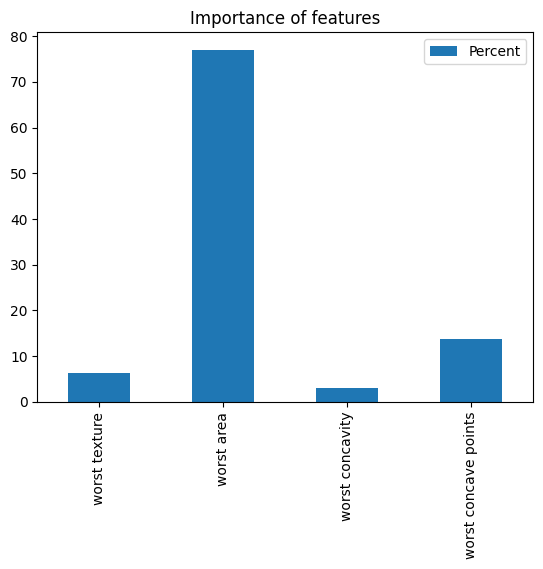

In [ ]:
# Important featuers graph
imp_features[imp_features["Percent"]>0].plot(kind='bar',title='Feature Importance')

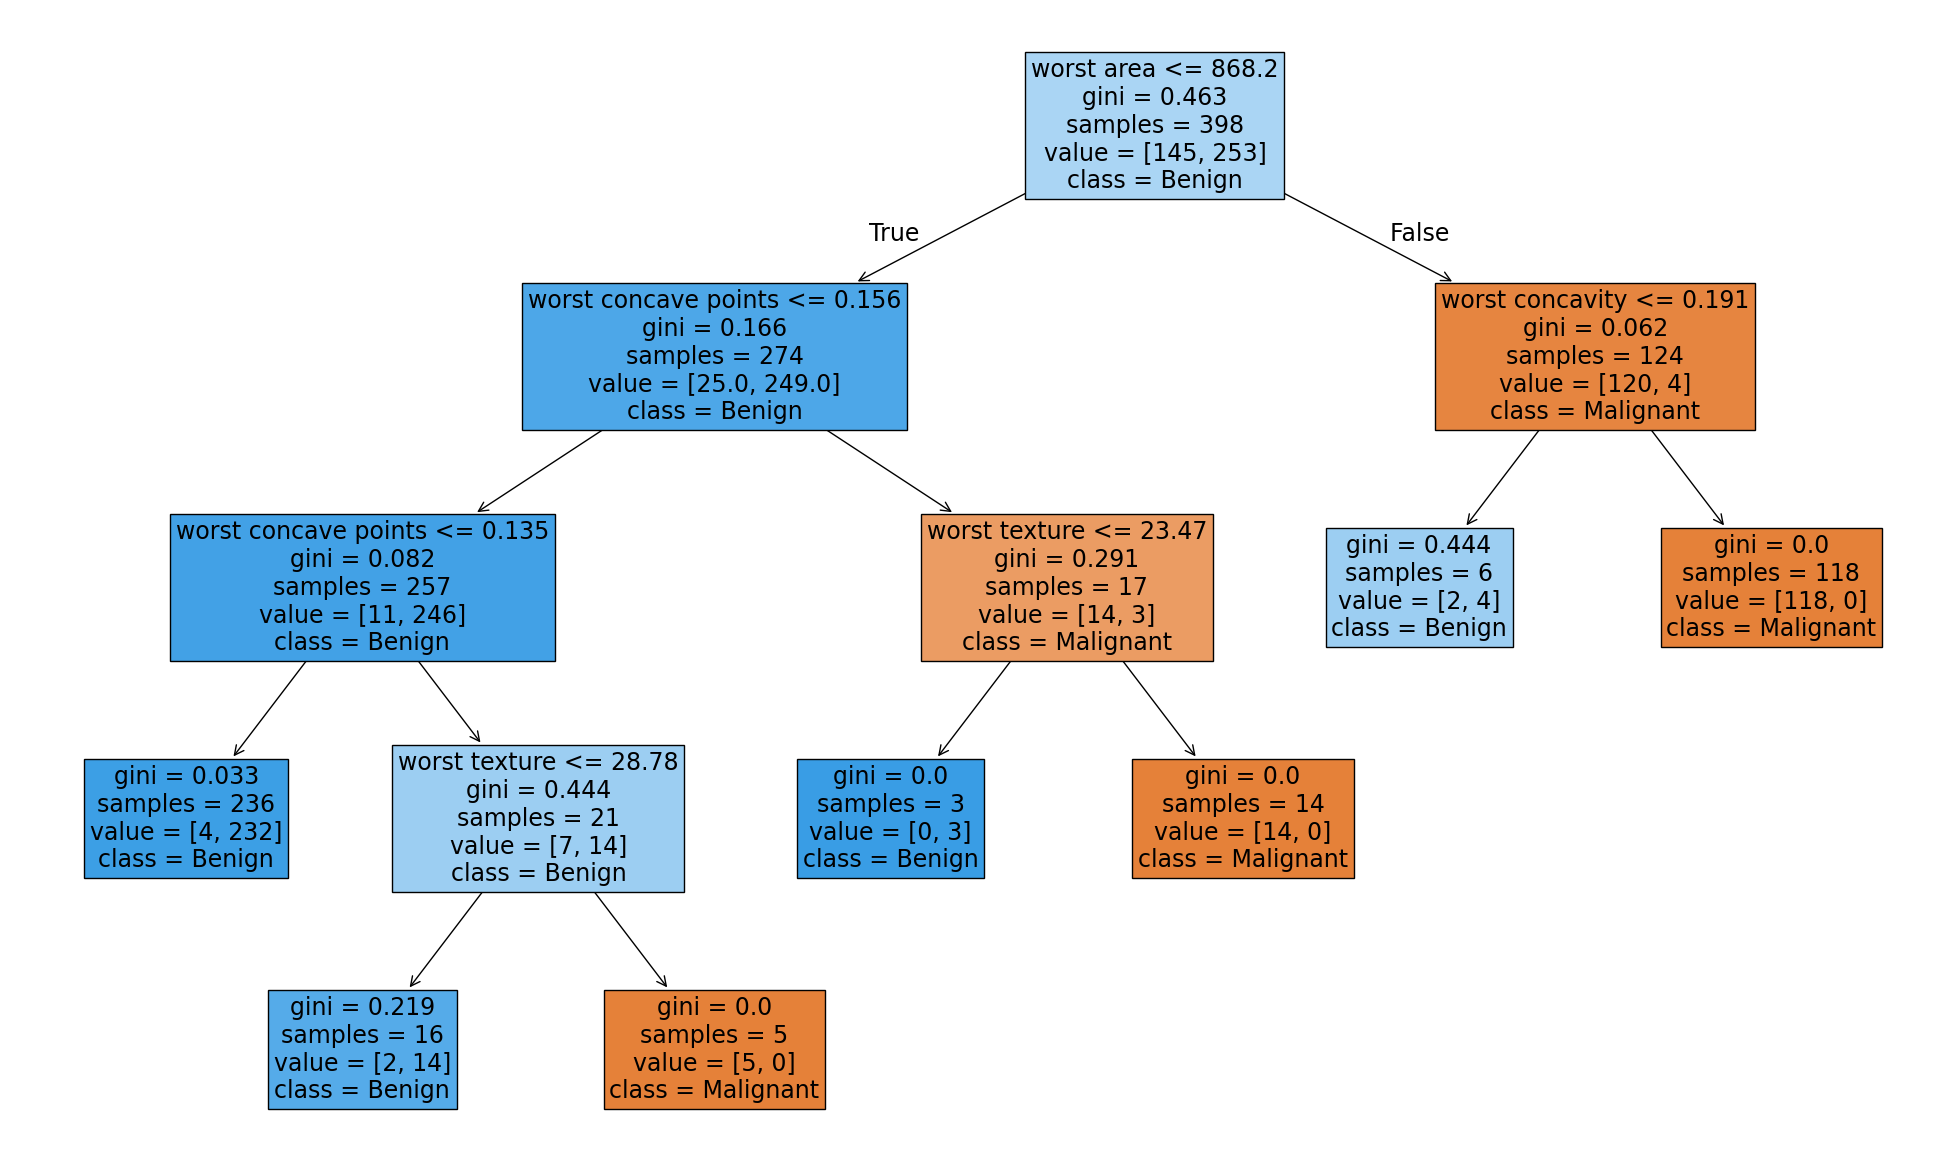

In [104]:
from sklearn import tree
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(25,15))
_ = tree.plot_tree(model,feature_names=data.feature_names,
               class_names={0:"Malignant",1:'Benign'},
               filled=True,fontsize=17)